In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WineQT.csv to WineQT.csv


In [ ]:
df = pd.read_csv("WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
print("Dimensões da base:")
print(df.shape)

print("\nColunas:")
print(df.columns.tolist())

print("\nTipos de dados:")
print(df.dtypes)

Dimensões da base:
(1143, 13)

Colunas:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Tipos de dados:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df['quality_binary'] = (df['quality'] >= 7).astype(int)

df[['quality', 'quality_binary']].head(10)

,quality,quality_binary
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0


In [ ]:
print(df['quality_binary'].value_counts())

print("\nPercentual das classes:")
print(df['quality_binary'].value_counts(normalize=True) * 100)

quality_binary
0    984
1    159
Name: count, dtype: int64

Percentual das classes:
quality_binary
0    86.089239
1    13.910761
Name: proportion, dtype: float64


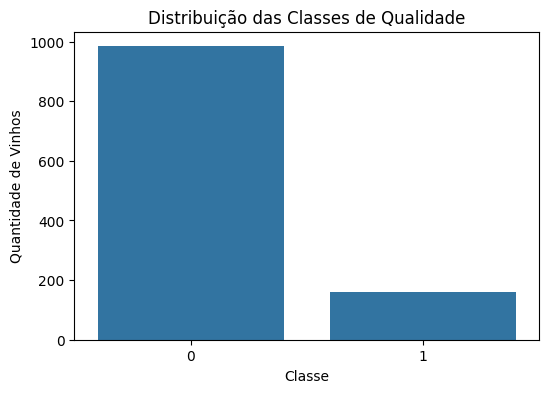

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x='quality_binary', data=df)

plt.title('Distribuição das Classes de Qualidade')
plt.xlabel('Classe')
plt.ylabel('Quantidade de Vinhos')

plt.show()

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


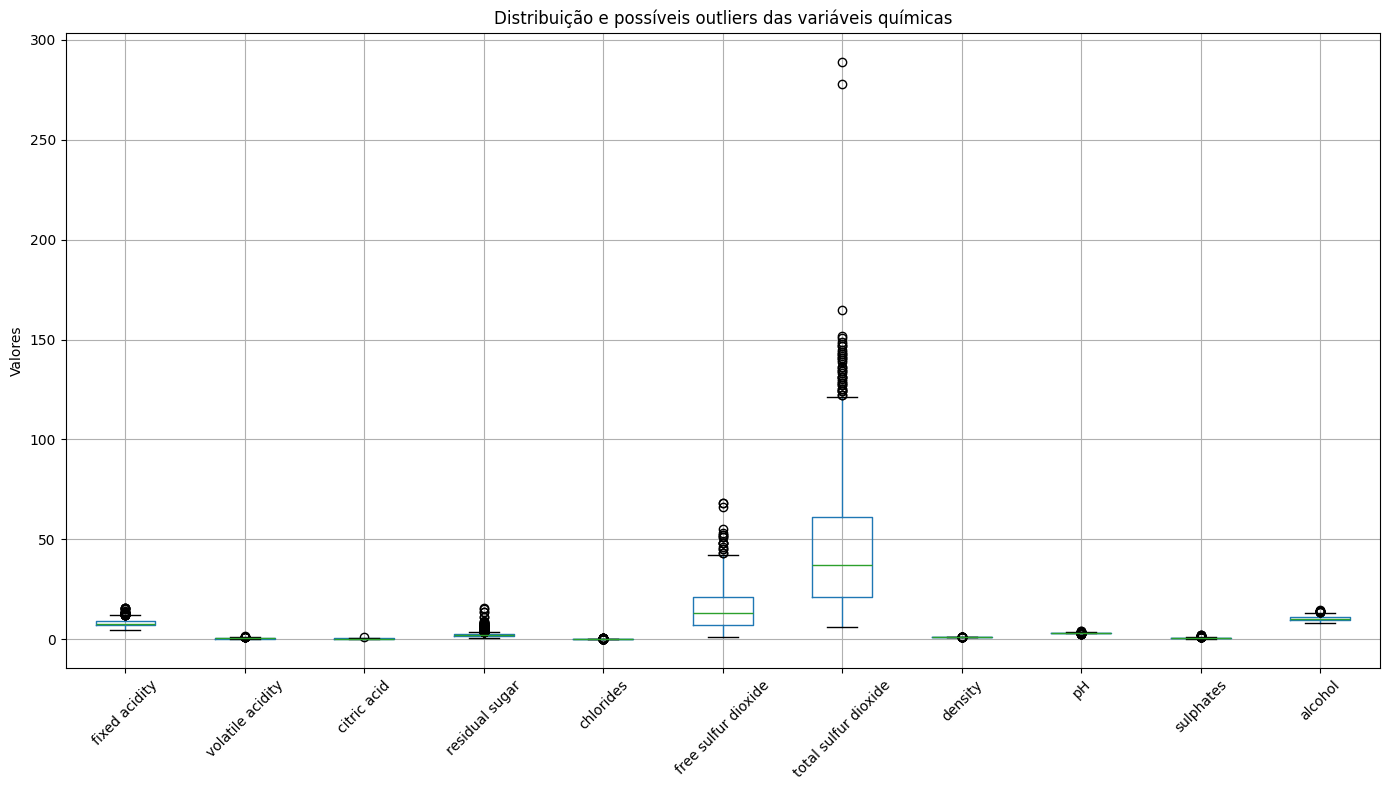

In [ ]:
plt.figure(figsize=(14, 8))

df.drop(columns=['quality', 'quality_binary', 'Id']).boxplot(rot=45)

plt.title('Distribuição e possíveis outliers das variáveis químicas')
plt.ylabel('Valores')
plt.tight_layout()
plt.show()

A análise da matriz de correlação mostrou que alcohol apresentou a maior correlação positiva com a variável de classificação binária (quality_binary), com coeficiente de aproximadamente 0,40. A variável volatile acidity apresentou correlação negativa de aproximadamente -0,30, enquanto citric acid e sulphates apresentaram correlações positivas de 0,25 e 0,21, respectivamente. As demais variáveis apresentaram correlações mais fracas com a variável alvo. Esses resultados indicam possíveis associações entre as características químicas e a qualidade dos vinhos, mas não permitem estabelecer relações de causalidade.


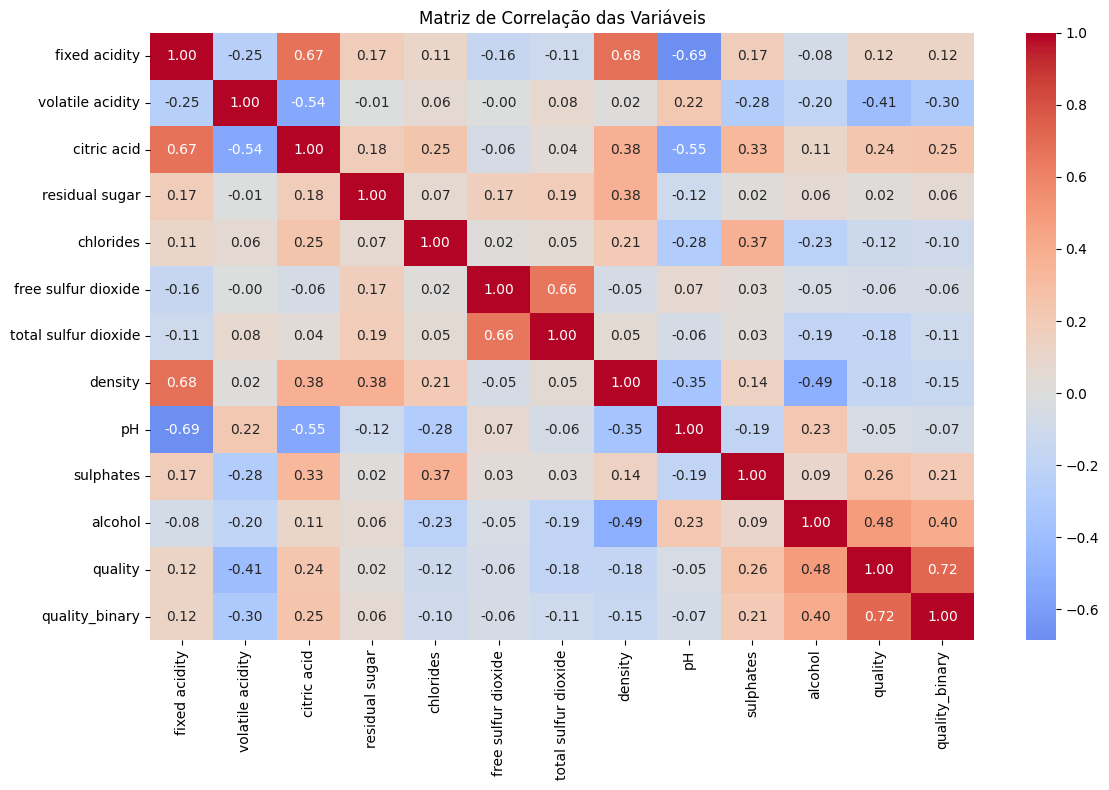

In [ ]:
plt.figure(figsize=(12, 8))

correlacao = df.drop(columns=['Id']).corr()

sns.heatmap(
    correlacao,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de Correlação das Variáveis')
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

df = pd.read_csv('WineQT.csv')

df['quality_binary'] = (df['quality'] >= 7).astype(int)

print("Base carregada!")
print("Formato:", df.shape)
print(df.columns.tolist())

Base carregada!
Formato: (1143, 14)
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id', 'quality_binary']


In [6]:
X = df[['alcohol', 'citric acid', 'pH', 'density', 'sulphates']]
y = df['quality_binary']

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (1143, 5)
Formato de y: (1143,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (914, 11)
X_test: (229, 11)
y_train: (914,)
y_test: (229,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Padronização concluída!")
print("Formato X_train_scaled:", X_train_scaled.shape)
print("Formato X_test_scaled:", X_test_scaled.shape)

Padronização concluída!
Formato X_train_scaled: (914, 11)
Formato X_test_scaled: (229, 11)


In [ ]:
scaler.fit_transform(X_train)

array([[-1.32097079, -0.16563837, -1.40086243, ...,  0.31786227,
        -1.24022797, -0.86830451],
       [ 1.12481966, -0.68126418,  0.7727959 , ..., -0.77749013,
        -0.21774894, -0.86830451],
       [ 0.61291003, -1.08230648,  0.51402705, ..., -0.58419265,
        -0.21774894, -1.1444886 ],
       ...,
       [ 0.66978888,  2.04009428, -0.00351065, ..., -0.45532766,
        -0.75906137, -0.96036587],
       [ 0.66978888, -0.3948054 ,  1.13507229, ..., -0.64862515,
         0.44385513,  0.51261593],
       [-0.46778807,  0.29269569, -1.24560112, ..., -1.87284254,
        -1.11993632, -1.1444886 ]])

In [ ]:
scaler.transform(X_test)

array([[ 0.32851579, -1.25418175,  0.46227328, ...,  0.57559225,
         0.20327183,  1.24910683],
       [-0.06963614, -1.65522405,  0.35876574, ..., -0.58419265,
         1.70691746,  0.42055457],
       [-1.77600157, -0.28022188, -1.19384735, ...,  1.47764718,
        -0.21774894,  1.61735229],
       ...,
       [ 1.97800238, -0.85313945,  1.4455949 , ..., -1.29295009,
        -0.21774894,  0.32849321],
       [ 0.49915234, -0.3948054 , -0.21052573, ..., -1.03522011,
        -0.87935302, -0.96036587],
       [-0.46778807,  0.34998745, -0.2622795 , ..., -1.35738259,
        -1.42066545, -1.1444886 ]])

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

modelo_logistico.fit(X_train_scaled, y_train)

print("Modelo de Regressão Logística treinado com sucesso!")

Modelo de Regressão Logística treinado com sucesso!


In [ ]:
y_pred = modelo_logistico.predict(X_test_scaled)
y_prob = modelo_logistico.predict_proba(X_test_scaled)[:, 1]

print("Previsões realizadas com sucesso!")
print("Quantidade de previsões:", len(y_pred))

Previsões realizadas com sucesso!
Quantidade de previsões: 229


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.7991
Precision: 0.3793
Recall:    0.6875
F1-score:  0.4889
ROC-AUC:   0.8504


Avaliação da Regressão Logística

A Regressão Logística apresentou uma acurácia de 79,91%. Entretanto, devido ao desbalanceamento das classes, outras métricas foram consideradas para uma avaliação mais adequada do modelo. A precisão foi de 37,93%, enquanto o recall atingiu 68,75%, indicando que o modelo conseguiu identificar aproximadamente 69% dos vinhos pertencentes à classe de maior qualidade. O F1-score foi de 48,89%, refletindo o equilíbrio entre precisão e recall. O modelo apresentou ROC-AUC de 85,04%, indicando uma boa capacidade de discriminação entre as duas classes. De modo geral, os resultados demonstram que a Regressão Logística possui capacidade relevante para distinguir vinhos de maior qualidade, embora ainda apresente limitações na precisão das classificações positivas.

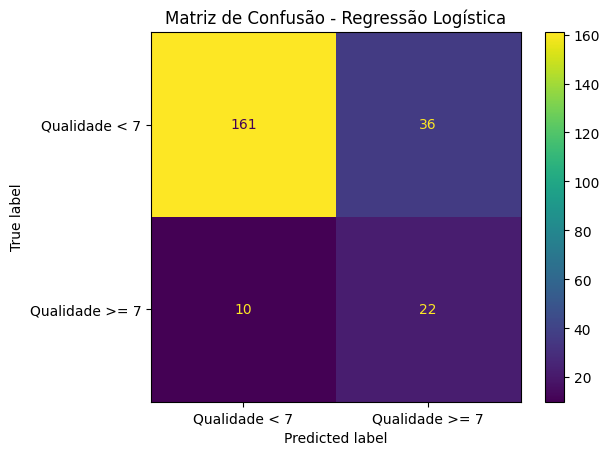

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Qualidade < 7', 'Qualidade >= 7']
)

disp.plot()
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

Matriz de Confusão

A matriz de confusão permite analisar detalhadamente o desempenho da Regressão Logística. O modelo classificou corretamente 161 vinhos da classe de qualidade inferior a 7 e 22 vinhos da classe de qualidade igual ou superior a 7. Foram observados 36 falsos positivos, nos quais vinhos com qualidade inferior a 7 foram classificados como de maior qualidade, e 10 falsos negativos, correspondentes a vinhos de qualidade igual ou superior a 7 classificados incorretamente como pertencentes à classe inferior.

A quantidade de falsos negativos é relativamente baixa, resultando em um recall de 68,75% para a classe de maior qualidade. Entretanto, o número de falsos positivos contribuiu para a redução da precisão do modelo, que foi de 37,93%.

In [ ]:
coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
})

coeficientes['Impacto_Absoluto'] = coeficientes['Coeficiente'].abs()

coeficientes = coeficientes.sort_values(
    by='Impacto_Absoluto',
    ascending=False
)

coeficientes

,Variável,Coeficiente,Impacto_Absoluto
10,alcohol,0.991160,0.991160
9,sulphates,0.682432,0.682432
6,total sulfur dioxide,-0.519930,0.519930
2,citric acid,0.485925,0.485925
1,volatile acidity,-0.467282,0.467282
4,chlorides,-0.420729,0.420729
3,residual sugar,0.329107,0.329107
7,density,-0.301383,0.301383
5,free sulfur dioxide,0.242067,0.242067
0,fixed acidity,0.177371,0.177371


Interpretação dos coeficientes da Regressão Logística

A análise dos coeficientes do modelo indica que alcohol apresentou a maior influência na classificação, com coeficiente positivo de aproximadamente 0,99, sugerindo uma associação entre maiores teores alcoólicos e maior probabilidade de o vinho pertencer à classe de qualidade igual ou superior a 7. sulphates também apresentou influência positiva relevante (0,68), seguido por citric acid (0,49).

Entre as variáveis com associação negativa, destacam-se total sulfur dioxide (-0,52), volatile acidity (-0,47) e chlorides (-0,42). Isso indica que, dentro do modelo, maiores valores dessas variáveis estão associados a uma menor probabilidade de classificação na classe de maior qualidade.

Como as variáveis foram padronizadas antes do treinamento, os coeficientes podem ser comparados em termos de magnitude. Entretanto, os resultados representam associações identificadas pelo modelo e não devem ser interpretados como relações causais.

## 5. Avaliação e interpretação da Regressão Logística

A Regressão Logística foi desenvolvida com o objetivo de classificar os vinhos em duas categorias: qualidade inferior a 7 (classe 0) e qualidade igual ou superior a 7 (classe 1).

O conjunto de dados foi dividido em 80% para treinamento e 20% para teste. As variáveis numéricas foram padronizadas antes do treinamento, garantindo que as diferentes escalas das características químicas não interferissem na modelagem.

O modelo apresentou Accuracy de 79,91%, Precision de 37,93%, Recall de 68,75%, F1-score de 48,89% e ROC-AUC de 85,04%.

Considerando o desbalanceamento das classes, a análise não deve ser baseada apenas na acurácia. O Recall de 68,75% indica que o modelo conseguiu identificar uma parcela relevante dos vinhos classificados como de maior qualidade. Além disso, o ROC-AUC de 85,04% demonstra uma boa capacidade de discriminação entre as duas classes.

A análise dos coeficientes indicou que `alcohol` apresentou a maior influência positiva na classificação, enquanto `sulphates` e `citric acid` também apresentaram associações positivas relevantes. Entre as variáveis com influência negativa, destacaram-se `total sulfur dioxide`, `volatile acidity` e `chlorides`.

Apesar do desempenho satisfatório em termos de discriminação, o modelo apresentou baixa Precision, indicando uma quantidade considerável de falsos positivos. Dessa forma, a Regressão Logística apresenta potencial para a classificação da qualidade dos vinhos, mas pode ser aprimorada por meio de outros modelos e estratégias de modelagem.

## 6. Conclusão do primeiro modelo

A primeira etapa da modelagem permitiu desenvolver uma pipeline completa de análise e classificação da qualidade dos vinhos utilizando Regressão Logística.

A análise exploratória identificou um forte desbalanceamento entre as classes, com 86,09% dos vinhos classificados como qualidade inferior a 7 e 13,91% como qualidade igual ou superior a 7. Também foram identificados possíveis valores extremos em algumas variáveis, principalmente em `total sulfur dioxide` e `free sulfur dioxide`.

As análises de correlação e os coeficientes do modelo indicaram que variáveis como `alcohol`, `sulphates`, `citric acid` e `volatile acidity` possuem maior associação com a classificação da qualidade.

A Regressão Logística apresentou ROC-AUC de 85,04%, demonstrando boa capacidade de distinguir as classes. Entretanto, a Precision de 37,93% evidencia que ainda existem oportunidades de melhoria na identificação dos vinhos de maior qualidade.

Como próxima etapa do projeto, um segundo algoritmo de classificação poderá ser desenvolvido e comparado à Regressão Logística, permitindo avaliar qual abordagem apresenta melhor desempenho para o problema proposto.

In [ ]:
print("===== RESUMO DO MODELO =====")
print(f"Registros utilizados: {len(df)}")
print(f"Variáveis preditoras: {X.shape[1]}")
print(f"Treinamento: {len(X_train)} registros")
print(f"Teste: {len(X_test)} registros")
print()
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

===== RESUMO DO MODELO =====
Registros utilizados: 1143
Variáveis preditoras: 11
Treinamento: 914 registros
Teste: 229 registros

Accuracy:  0.7991
Precision: 0.3793
Recall:    0.6875
F1-score:  0.4889
ROC-AUC:   0.8504


In [ ]:
# Previsões do modelo para toda a base
X_scaled = scaler.transform(X)

y_pred_all = modelo_logistico.predict(X_scaled)
y_prob_all = modelo_logistico.predict_proba(X_scaled)[:, 1]

# Métricas na base completa
accuracy_all = accuracy_score(y, y_pred_all)
precision_all = precision_score(y, y_pred_all)
recall_all = recall_score(y, y_pred_all)
f1_all = f1_score(y, y_pred_all)
roc_auc_all = roc_auc_score(y, y_prob_all)

print("===== AVALIAÇÃO NA BASE COMPLETA =====")
print(f"Accuracy:  {accuracy_all:.4f}")
print(f"Precision: {precision_all:.4f}")
print(f"Recall:    {recall_all:.4f}")
print(f"F1-score:  {f1_all:.4f}")
print(f"ROC-AUC:   {roc_auc_all:.4f}")

===== AVALIAÇÃO NA BASE COMPLETA =====
Accuracy:  0.7970
Precision: 0.3891
Recall:    0.8050
F1-score:  0.5246
ROC-AUC:   0.8859


Avaliação na base completa

Além da avaliação realizada no conjunto de teste, o modelo foi aplicado sobre os 1.143 registros da base completa. Nessa análise, foram obtidos Accuracy de 79,70%, Precision de 38,91%, Recall de 80,50%, F1-score de 52,46% e ROC-AUC de 88,59%.

Os resultados apresentam desempenho semelhante ao observado no conjunto de teste, com destaque para o aumento do Recall e do ROC-AUC. Entretanto, como parte dos dados utilizados nessa avaliação também participou do treinamento do modelo, esses resultados devem ser interpretados como uma análise complementar. Para avaliar a capacidade de generalização do modelo, os resultados do conjunto de teste permanecem como referência principal.